In [3]:
import sleap
import sys

sys.path.append('..')
from python.polygon_based_correction import *
from eval.eval import *

In [11]:
corrected_points_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0_tracked_points.npy'
corrected_points = np.load(corrected_points_path)
print(corrected_points.shape)

(9000, 17, 2)


total_range_length: 4264


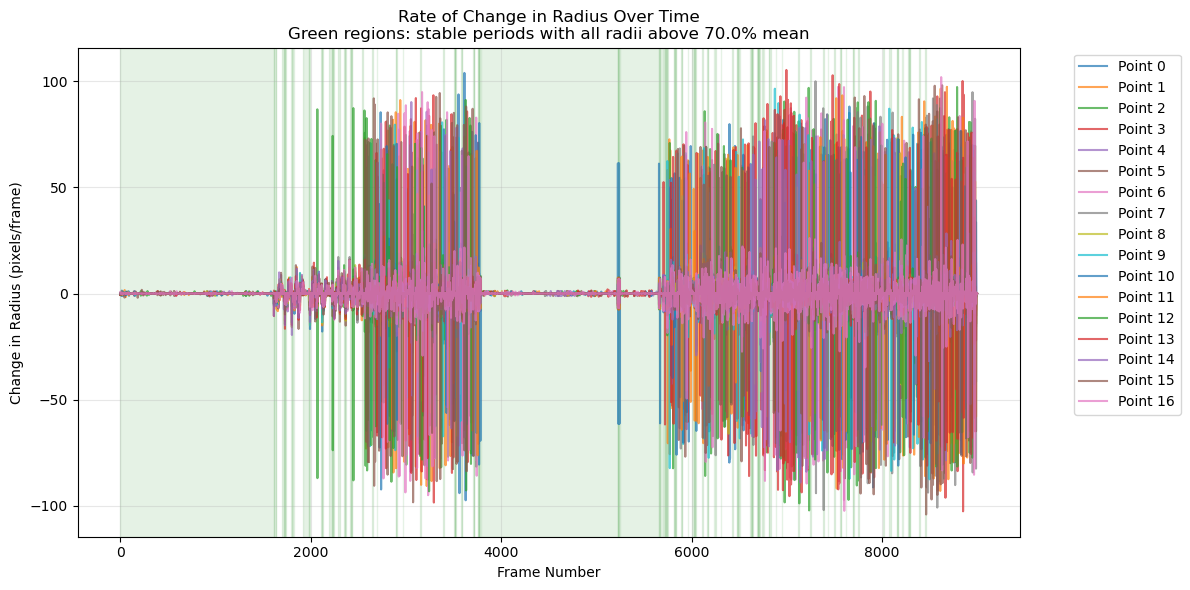

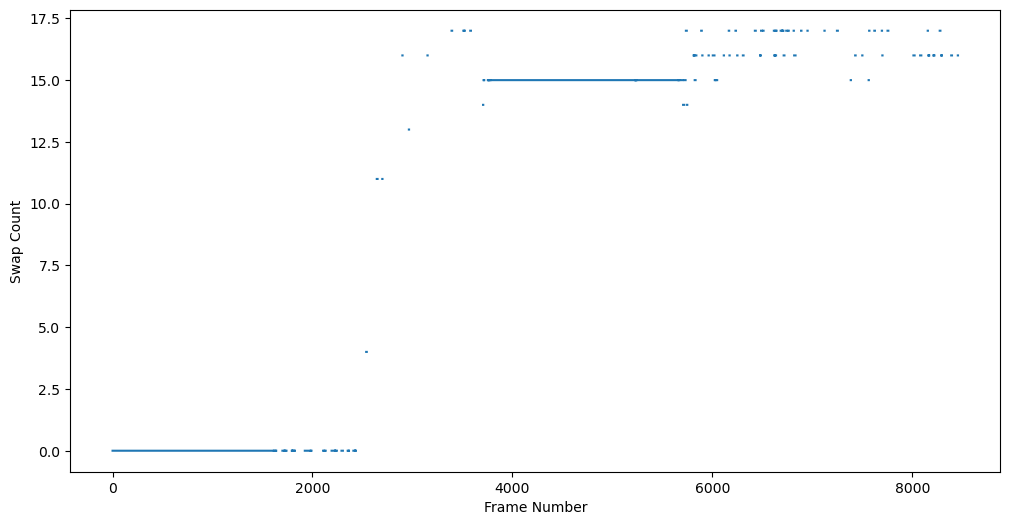

In [29]:
eval_dataset_from_points(corrected_points, method='polygon');

total_range_length: 5108


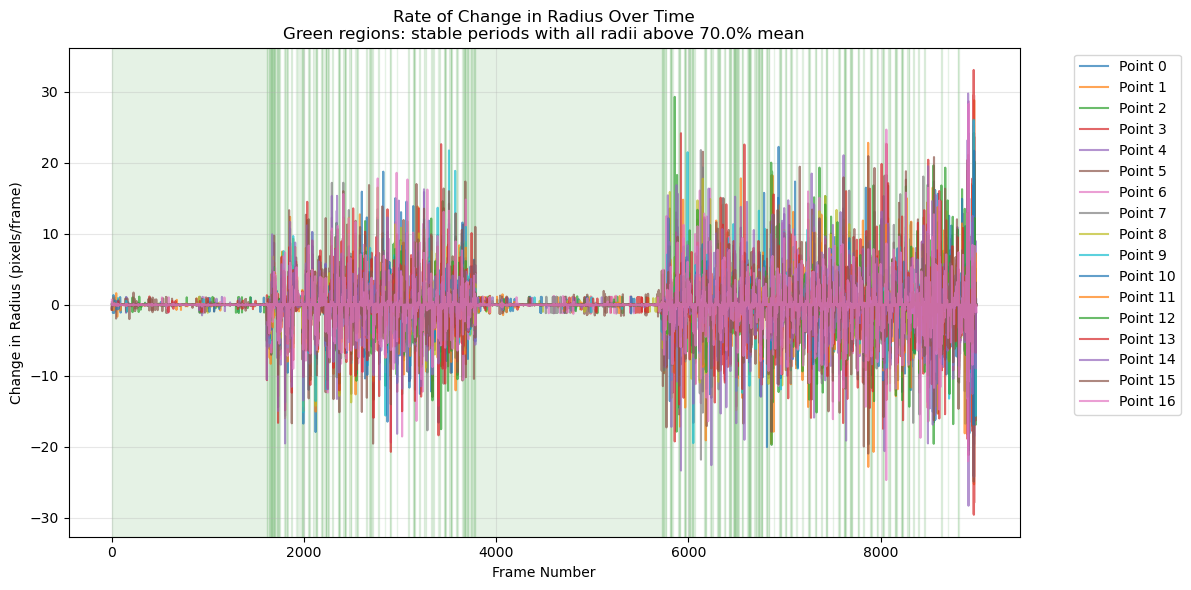

In [ ]:
poly_4_correction = polygon_correction_with_points(corrected_points, poly_4)
eval_dataset_from_points(poly_4_correction, method='polygon');

total_range_length: 1047


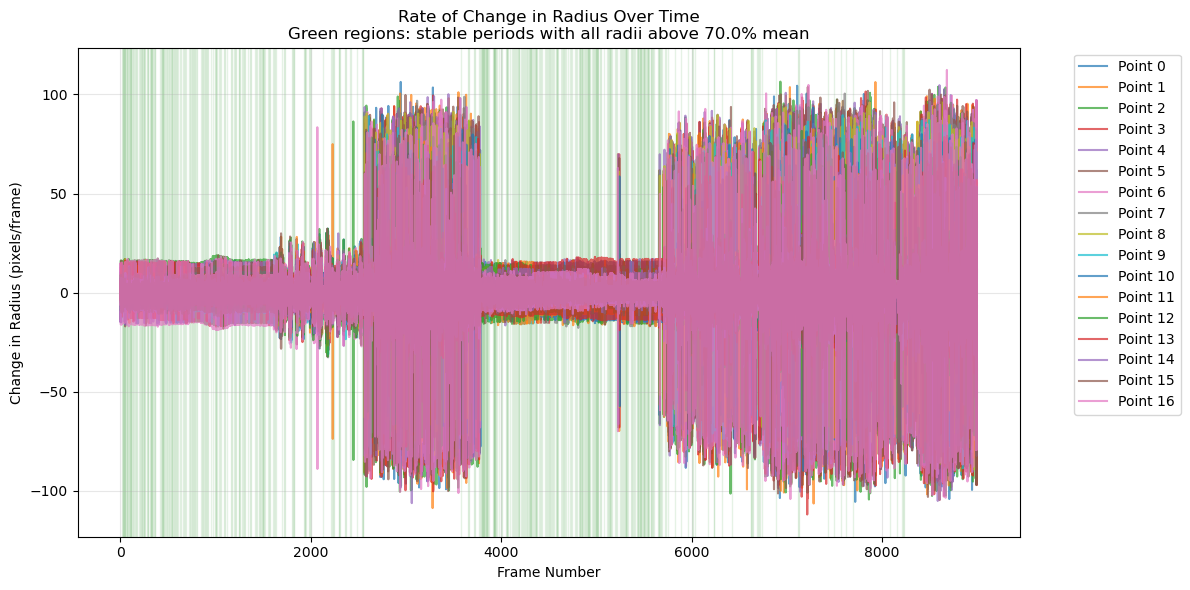

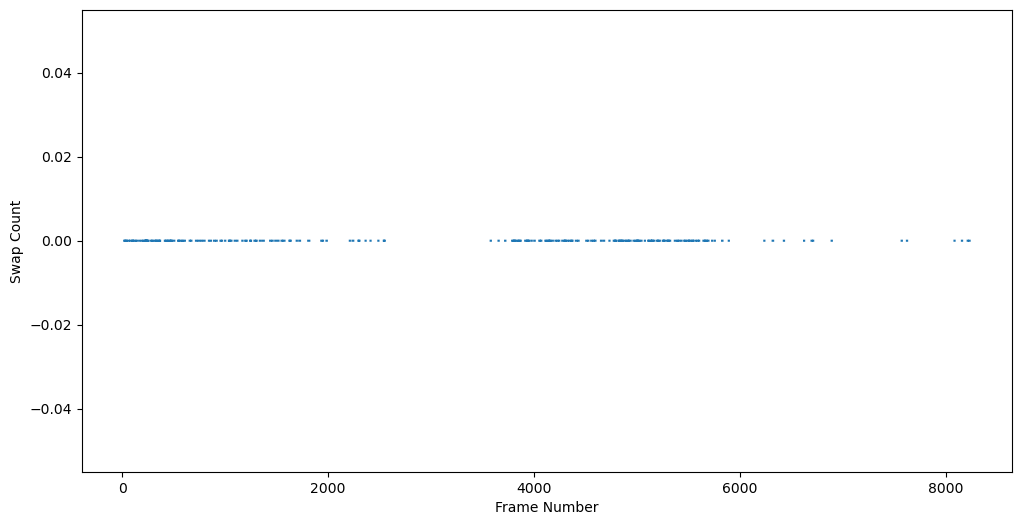

(array([nan, nan, nan, ..., nan, nan, nan]),
 array([[  19,   23],
        [  29,   34],
        [  40,   44],
        [  54,   66],
        [  71,   72],
        [  77,   87],
        [  98,  100],
        [ 105,  107],
        [ 117,  129],
        [ 139,  144],
        [ 149,  150],
        [ 164,  173],
        [ 191,  196],
        [ 206,  218],
        [ 223,  225],
        [ 230,  232],
        [ 237,  239],
        [ 244,  246],
        [ 252,  254],
        [ 276,  286],
        [ 291,  293],
        [ 310,  317],
        [ 327,  329],
        [ 335,  337],
        [ 343,  344],
        [ 349,  351],
        [ 360,  362],
        [ 367,  369],
        [ 414,  418],
        [ 424,  429],
        [ 434,  435],
        [ 441,  443],
        [ 448,  462],
        [ 467,  470],
        [ 476,  479],
        [ 489,  507],
        [ 522,  523],
        [ 537,  538],
        [ 543,  545],
        [ 550,  553],
        [ 565,  576],
        [ 587,  592],
        [ 607,  610],
        [

In [8]:
poly_3_correction = polygon_correction_with_points(corrected_points, poly_3)
eval_dataset_from_points(poly_3_correction, method='polygon')

In [15]:
c0_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
c0_dataset = sleap.load_file(c0_dataset_path)
print(c0_dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)


In [30]:
poly_3_correction, id_mappings_3 = polygon_correction_with_points(corrected_points, poly_3, return_indices=True)
poly_4_correction, id_mappings_4 = polygon_correction_with_points(corrected_points, poly_4, return_indices=True)

In [44]:
results_dir = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/'
poly_3_corrected_dataset = dataset_with_new_points(c0_dataset, poly_3_correction, handle_first_frame=False, node_name='tb')
poly_4_corrected_dataset = dataset_with_new_points(c0_dataset, poly_4_correction, handle_first_frame=False, node_name='tb')
poly_3_corrected_dataset.save(results_dir + 'poly_3_corrected_c0.slp')
poly_4_corrected_dataset.save(results_dir + 'poly_4_corrected_c0.slp')

missing_pt_cnt: 7440
missing_pt_cnt: 7440


In [45]:
poly_diff = (np.abs(id_mappings_3 - id_mappings_4) > 1).sum(axis=(1,))
print(poly_diff.shape)
print(len(poly_diff[poly_diff > 0]))

(9000,)

In [46]:
len(poly_diff[poly_diff > 0])

8827

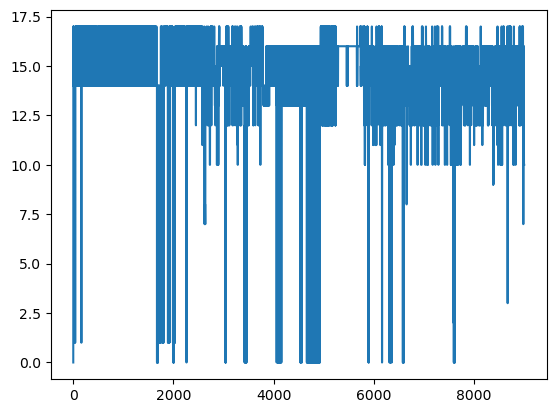

In [47]:
plt.plot(poly_diff);

In [36]:
frame_idx = 1000
print(id_mappings_3[frame_idx])
print(id_mappings_4[frame_idx])


[10  9  8  7  6  5  4  3  2  1  0 16 15 14 13 12 11]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [42]:
frame_idx = 4
print(id_mappings_3[frame_idx])
print(id_mappings_4[frame_idx])

[ 5  4  3  2  1  0 16 15 14 13 12 11 10  9  8  7  6]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [5]:
arr = np.array([[1, 2], [3, 4], [5, 6], [0, 0]])
arr.sum(axis=1) > 0

array([ True,  True,  True, False])

In [7]:
((arr - (1, 1) )**2).sum(axis=1)


array([ 1, 13, 41,  2])

In [24]:
def assign_id_to_points(all_tracked_points, frame_idx, polygon_constructor=poly_3):
    curr_frame_pts = all_tracked_points[frame_idx].copy()
    pt_cnt = len(curr_frame_pts)
    non_missing_mask = curr_frame_pts.sum(axis=1) > 0 # 1 = non-missing, 0 = missing
    
    if non_missing_mask.sum() == pt_cnt:
        assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor)
        return
    
    curr_id_mapping = [None for _ in range(pt_cnt)]
    prev_frame_pts = all_tracked_points[frame_idx-1]
    
    # for non-missing points, assign id based on nearest neighbor in previous frame
    matching_queue = [] # (dist, pt_idx, sorted_idx)
    for pt_idx in range(len(curr_frame_pts)):
        if not non_missing_mask[pt_idx]:
            continue
        dists = ((curr_frame_pts[pt_idx] - prev_frame_pts)**2).sum(axis=1)
        dists_sorted_idx = np.argmin(dists)
        # TODO: if the closest neighbor is too far away, this point may be mispredicted?
        matching_queue.append((dists[dists_sorted_idx], pt_idx, dists_sorted_idx))
    
    matching_queue.sort(key=lambda x: x[0])
    for _, pt_idx, sorted_idx in matching_queue:
        if sorted_idx not in curr_id_mapping:
            curr_id_mapping[pt_idx] = sorted_idx
            all_tracked_points[frame_idx][sorted_idx] = curr_frame_pts[pt_idx]
    
    # for missing points, impute from the previous frame
    for pt_idx in range(pt_cnt):
        if pt_idx in curr_id_mapping:
            continue
        all_tracked_points[frame_idx][pt_idx] = prev_frame_pts[pt_idx]
    
    # assign order again to ensure maximal global alignment
    assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor)
        
def assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor=poly_3):
    curr_frame_pts = all_tracked_points[frame_idx]
    polygon_order = polygon_constructor(curr_frame_pts)
    best_shift = find_best_roll(curr_frame_pts[polygon_order], all_tracked_points[frame_idx-1])
    shifted_indices = np.roll(polygon_order, best_shift, axis=0)
    all_tracked_points[frame_idx] = curr_frame_pts[shifted_indices]

def polygon_correction_with_points(all_tracked_points, polygon_constructor=poly_3, return_indices=False):

    frame_cnt = all_tracked_points.shape[0]
    corrected_coords = all_tracked_points.copy()

    for frame_idx in range(1, frame_cnt):
        assign_id_to_points(corrected_coords, frame_idx, polygon_constructor)

    # # corrected_coords = get_corrected_coords(all_tracked_points, id_mapping)
    # if return_indices:
    #     return corrected_coords, id_mapping
    # else:
    return corrected_coords

In [13]:
poly_3_correction_v3 = polygon_correction_with_points(corrected_points, poly_3, return_indices=True)
poly_4_correction_v3 = polygon_correction_with_points(corrected_points, poly_4, return_indices=True)

In [16]:
results_dir = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/'
poly_3_corrected_dataset_v3 = dataset_with_new_points(c0_dataset, poly_3_correction_v3, handle_first_frame=False, node_name='tb')
poly_4_corrected_dataset_v3 = dataset_with_new_points(c0_dataset, poly_4_correction_v3, handle_first_frame=False, node_name='tb')
poly_3_corrected_dataset_v3.save(results_dir + 'poly_3_corrected_c0_v3.slp')
poly_4_corrected_dataset_v3.save(results_dir + 'poly_4_corrected_c0_v3.slp')

missing_pt_cnt: 0
missing_pt_cnt: 0


In [23]:
poly_diff = (np.abs(poly_3_correction_v3 - poly_4_correction_v3) > 20).sum(axis=(1,2))
print(poly_diff.shape)
print(len(poly_diff[poly_diff > 0]))

(9000,)
8514


In [25]:
poly_3_correction_v4 = polygon_correction_with_points(corrected_points, poly_3, return_indices=True)
poly_4_correction_v4 = polygon_correction_with_points(corrected_points, poly_4, return_indices=True)

In [26]:
results_dir = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/'
poly_3_corrected_dataset_v4 = dataset_with_new_points(c0_dataset, poly_3_correction_v4, handle_first_frame=False, node_name='tb')
poly_4_corrected_dataset_v4 = dataset_with_new_points(c0_dataset, poly_4_correction_v4, handle_first_frame=False, node_name='tb')
poly_3_corrected_dataset_v4.save(results_dir + 'poly_3_corrected_c0_v4.slp')
poly_4_corrected_dataset_v4.save(results_dir + 'poly_4_corrected_c0_v4.slp')

missing_pt_cnt: 0
missing_pt_cnt: 0


In [27]:
poly_3_correction_v5 = polygon_correction_with_points(corrected_points, poly_3, return_indices=True)
poly_4_correction_v5 = polygon_correction_with_points(corrected_points, poly_4, return_indices=True)

In [28]:
results_dir = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/'
poly_3_corrected_dataset_v5 = dataset_with_new_points(c0_dataset, poly_3_correction_v5, handle_first_frame=False, node_name='tb')
poly_4_corrected_dataset_v5 = dataset_with_new_points(c0_dataset, poly_4_correction_v5, handle_first_frame=False, node_name='tb')
poly_3_corrected_dataset_v5.save(results_dir + 'poly_3_corrected_c0_v5.slp')
poly_4_corrected_dataset_v5.save(results_dir + 'poly_4_corrected_c0_v5.slp')

missing_pt_cnt: 0
missing_pt_cnt: 0
